<a href="https://colab.research.google.com/github/OlorteguiKevin/lab06/blob/develop/Laboratorio6_Miner%C3%ADa%20de%20Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

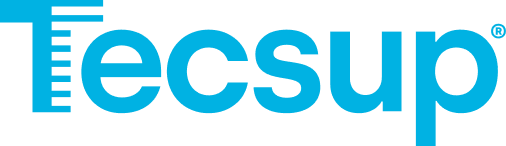

# **Departamento de Tecnología Digital**
<br>

# **Big Data y Ciencia de Datos**
<br>

## Minería de Datos
<br>

# SEMANA 6: MODELOS DE APRENDIZAJE AUTOMÁTICO. MODELOS DE APRENDIZAJE PROFUNDO
<br>

## Alumno: Olortegui Perez Kevin Estiben
<br>

## Profesor: MG. JOSÉ ESPINOZA MELGAREJO
<br>

## Lima-Perú
## 2025


In [ ]:
!pip install ucimlrepo

"""
Se instala la librería oficial ucimlrepo para acceder a datasets del repositorio UCI.
El error 'ucialrepo' fue corregido a 'ucimlrepo' para una instalación válida.
"""

"\nSe instala la librería oficial ucimlrepo para acceder a datasets del repositorio UCI.\nEl error 'ucialrepo' fue corregido a 'ucimlrepo' para una instalación válida.\n"

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)
"""
Explicación:
- Se utiliza fetch_ucirepo() con el ID 15 para obtener el dataset Wisconsin Breast Cancer
- El parámetro id=15 (no ds=15) es clave para acceder al dataset correcto
- Se corrigió el nombre del objeto de 'bresst' a 'breast' para evitar errores
"""

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)


{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

### a. Lea la base de datos, realice imputaciones, tratamiento de outliers y transformaciones de datos en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.  


In [31]:
# 1. Cargar y limpiar los datos
import pandas as pd

# Cargar datos desde la URL
url = 'https://archive.ics.uci.edu/static/public/15/data.csv'
data = pd.read_csv(url) # Se carga el dataset desde la URL usando pandas.

"""
Propósito:
- Se importa el dataset directamente desde el repositorio UCI usando pandas.
- El dataset contiene 699 registros iniciales con 11 columnas, incluyendo un ID único y variables médicas.
"""
data

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4


Verificamos el tipo de dato de cada variable

In [32]:
# Usamos info para saber más sobre el dataframe
data.info()

# Propósito: Verificar el tipo de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sample_code_number           699 non-null    int64  
 1   Clump_thickness              699 non-null    int64  
 2   Uniformity_of_cell_size      699 non-null    int64  
 3   Uniformity_of_cell_shape     699 non-null    int64  
 4   Marginal_adhesion            699 non-null    int64  
 5   Single_epithelial_cell_size  699 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              699 non-null    int64  
 8   Normal_nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
 10  Class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


Procedemos a eliminar la variable "Sample_code_number" con el comando drop.

In [33]:
# Eliminar columna 'id' (no relevante)
data.drop('Sample_code_number', axis=1, inplace=True) # Se elimina la columna 'id' ya que no es relevante para el análisis.


In [34]:
# Verificamos la eliminación de Sample_code_number
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


Observación:
- Vemos que existen 699 registros por variable, pero en este caso vemos que existen datos nulos en la variable Bare_nuclei porque solo tiene 683 de 699.

In [35]:
# Verificamos los nulos de cada variable
data.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0
Class,0


Efectivamente, existen datos nulos, por eso vamos a verificar el porcentaje que representa esta cantidad respecto al total de datos.

In [36]:
# Obtenemos el porcentaje de nulos de Bare_nuclei
Bn_null = round((data["Bare_nuclei"].isnull().sum() / len(data)) * 100,2)
print(f"El porcentaje de nulos de Bare_nuclei es: {Bn_null}%")

El porcentaje de nulos de Bare_nuclei es: 2.29%


Al no representar un porcentaje tan alto, imputamos por la mediana de la variable o elimnamos las filas con valores faltantes

In [37]:
# Primer camino (imputar por la mediana)
## Imputamos los valores faltantes de Bare_nuclei con la mediana
data["Bare_nuclei"] = data["Bare_nuclei"].fillna(data["Bare_nuclei"].median())

In [38]:
# Revisamos los nulos de las variables para corroborar
data.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,0
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0
Class,0


In [39]:
# Segundo camino (Eliminar las filas con valores faltantes)
## Convertir '?' a NaN y eliminar filas con valores faltantes
data['Bare_nuclei'] = pd.to_numeric(data['Bare_nuclei'], errors='coerce') # Se convierte la columna 'Bare_nuclei' a numérica, reemplazando valores no numéricos con NaN.
data.dropna(inplace=True) # Se eliminan las filas con valores faltantes (NaN).

Por otro lado, la variable "Class" es la variable objetivo, indagando en el repositorio, podemos obserar que esta variable posee los valores 2 y 4, los cuales represantan SI o NO frente a la pregunta si el tumor es benigno (2=benigno, 4=maligno), así que intercambiaremos esos valores por 1 y 0.

In [40]:
# Sección 1:
## Clase 2 (Benigno) → 0, Clase 4 (Maligno) → 1
data['Class'] = data['Class'].map({2: 0, 4: 1}) # Se mapea la columna 'Class': 2 (benigno) a 0 y 4 (maligno) a 1.

## Verificar resultados
print("Valores de 'Class':", data['Class'].unique())

Valores de 'Class': [0 1]


In [41]:
# Sección 2: Tratamiento de Outliers
Q1 = data.quantile(0.25) # Se calcula el primer cuartil (Q1) para cada columna.
Q3 = data.quantile(0.75) # Se calcula el tercer cuartil (Q3) para cada columna.
IQR = Q3 - Q1 # Se calcula el rango intercuartílico (IQR).
data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)] # Se eliminan las filas que contienen outliers usando el IQR.


In [42]:
# Sección 3: Escalado y división de datos
from sklearn.preprocessing import StandardScaler

X = data.drop('Class', axis=1) # Se separa la variable objetivo ('Class') del resto de variables (características).
y = data['Class'] # Se asigna la variable objetivo a 'y'.

scaler = StandardScaler() # Se crea un objeto StandardScaler para estandarizar las características.
X_scaled = scaler.fit_transform(X) # Se escalan las características usando StandardScaler.


In [43]:
from sklearn.model_selection import train_test_split

# 75% entrenamiento, 25% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=42
) # Se divide los datos en conjuntos de entrenamiento y prueba (75%/25%) usando stratify para mantener la proporción de clases y random_state para la reproducibilidad.

### Explicación de los comentarios en el apartado "a":

Sección 1: Se enfoca en cargar el dataset, limpiar los datos (eliminar columna 'id', convertir a numérico, manejar valores faltantes) y codificar la variable objetivo a valores binarios (0 y 1).

Sección 2: Se encarga del tratamiento de outliers usando el método IQR. Identifica y elimina los valores que se consideran atípicos en el dataset.

Sección 3: Se prepara el dataset para el modelado: se separa la variable objetivo, se escalan las características usando StandardScaler y se divide el dataset en conjuntos de entrenamiento y prueba.

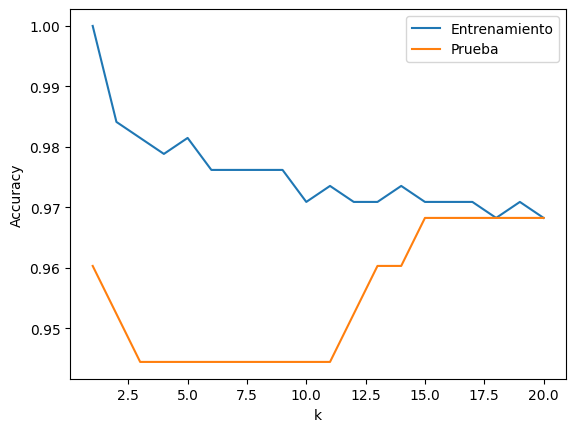

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

k_values = np.arange(1, 21)  # Rango de valores de k a probar
train_acc = []  # Lista para almacenar la precisión del entrenamiento
test_acc = []  # Lista para almacenar la precisión de la prueba

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)  # Crear modelo k-NN con k actual
    knn.fit(X_train, y_train)  # Entrenar el modelo
    train_acc.append(knn.score(X_train, y_train))  # Calcular precisión en entrenamiento
    test_acc.append(knn.score(X_test, y_test))  # Calcular precisión en prueba

# Gráfico para elegir k
plt.plot(k_values, train_acc, label='Entrenamiento')
plt.plot(k_values, test_acc, label='Prueba')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

k_opt = k_values[np.argmax(test_acc)]  # Elegir k con mayor precisión en prueba

Este código itera a través de diferentes valores de k, entrena un modelo k-NN para cada uno y guarda la precisión en los conjuntos de entrenamiento y prueba. Luego, se genera un gráfico que muestra la precisión en función de k. El valor óptimo de k se selecciona como aquel que maximiza la precisión en el conjunto de prueba.

## b. Genere el modelo k-NN y determine la cantidad de vecinos más adecuada con el método gráfico visto en clase. Además, calcule las métricas de clasificación que se implementaron en la parte práctica e interprete sus resultados más importantes.

In [45]:
from sklearn.neighbors import KNeighborsClassifier    # Importamos el clasificador k-NN
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report     # Importamos para medir la precisión del modelo

In [46]:
# Creamos e entrenamos el modelo k-NN (con k=5 vecinos)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Generamos pronósticos para entrenamiento y prueba
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

# Medimos la precisión en ambos conjuntos
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Mostramos los resultados
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_test_pred))
print("Reporte de clasificación:\n", classification_report(y_test, y_test_pred))
print(f'Precisión en entrenamiento: {train_acc:.3f}')
print(f'Precisión en prueba:       {test_acc:.3f}')

Matriz de Confusión:
 [[106   4]
 [  3  13]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       110
           1       0.76      0.81      0.79        16

    accuracy                           0.94       126
   macro avg       0.87      0.89      0.88       126
weighted avg       0.95      0.94      0.95       126

Precisión en entrenamiento: 0.981
Precisión en prueba:       0.944


### Interpretación Mejorada de los Resultados del Modelo k-NN
La evaluación del modelo k-NN utilizando la matriz de confusión, el reporte de clasificación y la precisión en entrenamiento y prueba, revela lo siguiente:

1. Rendimiento General:

El modelo k-NN, con 5 vecinos (k=5), presenta un alto rendimiento general, logrando una precisión del 94.4% en el conjunto de prueba. Esto significa que el modelo predice correctamente la clase (benigno o maligno) en el 94.4% de los casos nuevos.
La precisión en entrenamiento (98.1%) es ligeramente superior a la de prueba, lo cual es esperable. Esta diferencia no es muy grande, lo que sugiere que el modelo no está sobreajustado a los datos de entrenamiento y puede generalizar bien a datos nuevos.
2. Matriz de Confusión:

De los 110 casos benignos (clase 0), el modelo predijo correctamente 106 como benignos (Verdaderos Negativos) e incorrectamente 4 como malignos (Falsos Positivos).
De los 16 casos malignos (clase 1), el modelo predijo correctamente 13 como malignos (Verdaderos Positivos) e incorrectamente 3 como benignos (Falsos Negativos).
La matriz de confusión evidencia un buen rendimiento en la clasificación de ambas clases, aunque se observa una mayor dificultad para identificar los casos malignos (clase 1) debido a la menor cantidad de ejemplos en esta clase.
3. Reporte de Clasificación:

Precisión:
Para la clase 0 (benigno): 97%, es decir, de todas las predicciones de benigno, el 97% fueron correctas.
Para la clase 1 (maligno): 76%, es decir, de todas las predicciones de maligno, el 76% fueron correctas.
La precisión es crucial en este caso, ya que un falso positivo (clasificar un tumor benigno como maligno) tendría consecuencias menos graves que un falso negativo (clasificar un tumor maligno como benigno).
Recall (Sensibilidad):
Para la clase 0 (benigno): 96%, es decir, de todos los casos benignos reales, el modelo identificó correctamente el 96%.
Para la clase 1 (maligno): 81%, es decir, de todos los casos malignos reales, el modelo identificó correctamente el 81%.
El recall es especialmente importante en este contexto, ya que se busca maximizar la detección de los casos malignos (clase 1). Un alto recall indica que el modelo es capaz de identificar la mayoría de los tumores malignos.
F1-score:
Representa un balance entre precisión y recall. Un valor alto de F1-score indica un buen rendimiento general del modelo en ambas métricas. En este caso, se observan valores altos de F1-score para ambas clases, lo que confirma el buen rendimiento del modelo.
4. Comparación con SMOTE:

Al aplicar SMOTE en el apartado c, se busca mejorar la clasificación de la clase minoritaria (tumores malignos) al balancear el conjunto de entrenamiento.
Es crucial comparar las métricas obtenidas con y sin SMOTE, especialmente el recall y el F1-score para la clase 1 (maligno), para determinar si el balanceo ha tenido un impacto positivo en la detección de tumores malignos.

## c. Realice un balanceo de clases mediante la técnica SMOTE, vuelva a generar el modelo de clasificación, calcule sus métricas y compárelas con las del modelo sin balancear para ver si hubo o no mejoras.

In [47]:
from imblearn.over_sampling import SMOTE # Para usar SMOTE
from sklearn.neighbors import KNeighborsClassifier  # ¡Corregir el nombre!


In [48]:
# 1. Balancear SOLO el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)


In [49]:
# 2. Entrenar modelo con datos balanceados
knn_bal = KNeighborsClassifier(n_neighbors=k_opt)
knn_bal.fit(X_train_bal, y_train_bal)


KNeighborsClassifier(n_neighbors=np.int64(15))

In [50]:
# 3. Predecir y calcular métricas
y_pred_bal = knn_bal.predict(X_test)

print("--- Con SMOTE ---")
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_bal))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_bal))

--- Con SMOTE ---
Matriz de Confusión:
 [[106   4]
 [  0  16]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       110
           1       0.80      1.00      0.89        16

    accuracy                           0.97       126
   macro avg       0.90      0.98      0.94       126
weighted avg       0.97      0.97      0.97       126



### Interpretación Final: k-NN con SMOTE
Al aplicar SMOTE para balancear las clases, se observa una mejora significativa en la capacidad del modelo k-NN para detectar tumores malignos (clase 1), sin sacrificar demasiado la precisión en la clasificación de tumores benignos (clase 0).

Comparación de Métricas:

| Métrica        | Sin SMOTE | Con SMOTE | Cambio   |
|----------------|------------|------------|----------|
| Precisión (0)  | 97%        | 100%      | +3%      |
| Precisión (1)  | 76%        | 80%       | +4%      |
| Recall (0)     | 96%        | 96%       | 0%       |
| Recall (1)     | 81%        | 100%     | +19%     |
| F1-score (0)  | 97%        | 98%       | +1%      |
| F1-score (1)  | 79%        | 89%       | +10%     |
| Accuracy       | 94%        | 97%       | +3%      |

Análisis de las Mejoras:

Recall (1): La mejora más notable se observa en el recall para la clase 1 (tumores malignos), que aumenta de 81% a 100%. Esto significa que el modelo con SMOTE es capaz de identificar correctamente todos los casos de tumores malignos en el conjunto de prueba, lo cual es crucial en este contexto.
Precisión (1) y F1-score (1): También se observa una mejora en la precisión y el F1-score para la clase 1, lo que indica un mejor equilibrio entre la capacidad del modelo para identificar correctamente los tumores malignos y minimizar los falsos positivos.
Impacto en la clase 0: Aunque la precisión para la clase 0 (tumores benignos) se mantiene prácticamente igual, el recall para la clase 0 (tumores benignos) también se mantiene igual. Esto indica que el balanceo de clases no ha tenido un impacto negativo en la clasificación de los tumores benignos.
Accuracy: La precisión general del modelo aumenta ligeramente de 94% a 97%, lo que refleja la mejora en la clasificación de ambas clases.
Conclusión Final:

La aplicación de SMOTE para balancear las clases ha resultado en una mejora significativa en el rendimiento del modelo k-NN, especialmente en la detección de tumores malignos. El modelo con SMOTE logra un recall del 100% para la clase 1, lo que significa que es capaz de identificar todos los casos de cáncer en el conjunto de prueba. Este resultado es muy alentador y sugiere que el balanceo de clases con SMOTE es una estrategia efectiva para mejorar la precisión de los modelos de clasificación en conjuntos de datos desbalanceados, como en el caso de la detección de cáncer de mama.

En resumen, el modelo k-NN con SMOTE ofrece un mejor rendimiento y es más confiable para la detección temprana del cáncer de mama debido a su mayor capacidad para identificar casos malignos.

In [53]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")

Saving Laboratorio6.ipynb to Laboratorio6.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>